Este cuaderno es la versión interactiva del capítulo 7 del libro, y está orientada a Colab. Contiene únicamente el código Python; para las explicaciones teóricas y el código R consulta el libro en:

[https://juanriera.github.io/master-queseria/](https://juanriera.github.io/master-queseria/)

Para utilizar los datos de ejemplo, descarga el CSV en el enlace a continuacion y súbelo al espacio de trabajo de Colab.

[Descargar los datos de ejemplo utilizados en este cuaderno (archivo `fab_queso_sim.csv`)](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_sim.csv)

Antes de lanzarnos al análisis cuantitativo, siempre es conveniente una primera visualización de los datos, por si hubiese algún valor que nos pueda resultar cuestionable. 

Es una mala práctica, aunque muy extendida, lanzarse a la hoja de cálculo para hacer la media aritmética de cada parámetro que vayamos a utilizar y trabajar con estos valores medios. En un conjunto de datos que recoja muchas fabricaciones, nunca podemos estar seguros de que el 100% de los valores sean correctos, que no haya habido errores de muestreo, analíticos o problemas de fabricación que hayan producido valores anormales. Por eso vamos a utilizar siempre los valores *medianos* y no los valores medios; como sabemos, la **mediana** es resistente a los valores anormales y extremos, mientras que la media no lo es.

## Lectura y preparación de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_style("whitegrid")

In [2]:
# El CSV de datos debe estar en el espacio de trabajo de Google Colab
url_datos = "datos/02-fab_queso_sim.csv"

try:
    df = pd.read_csv(url_datos, 
                     decimal = ",", 
                     sep=';', 
                     encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                364 non-null    object 
 1   entrada_kg           260 non-null    float64
 2   entrada_litros       260 non-null    float64
 3   entrada_grasa_g_l    260 non-null    float64
 4   entrada_prot_g_l     260 non-null    float64
 5   cuba_fab_litros      260 non-null    float64
 6   cuba_fab_grasa_g_l   260 non-null    float64
 7   cuba_fab_prot_g_l    260 non-null    float64
 8   stock_cierre_litros  260 non-null    float64
 9   queso_kg             260 non-null    float64
 10  queso_est_pct        260 non-null    float64
 11  queso_mg_pct         260 non-null    float64
dtypes: float64(11), object(1)
memory usage: 34.3+ KB


Una vez leído correctamente, convertimos la columna 'fecha' en formato de fecha y añadimos un índice para `pandas`:

In [4]:
# 1. Damos formato fecha a la columna 'fecha' 
df['fecha'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y', # Formato Día/Mes/Año confirmado
    errors='coerce'    # convierte los valores que no puede leer a NaT
)
# 2. Creamos la nueva columna que será el índice
df['fecha_index'] = df['fecha']

# 3. La establecemos como índice
#    Usamos inplace=True para modificar el dataframe original directamente
#    Limpiamos NaT y establecer el índice ordenado
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

In [5]:
df.head()

,fecha,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,cuba_fab_litros,cuba_fab_grasa_g_l,cuba_fab_prot_g_l,stock_cierre_litros,queso_kg,queso_est_pct,queso_mg_pct
fecha_index,,,,,,,,,,,,
2023-12-31,2023-12-31,4895.0,4752.0,45.13,36.68,NaN,NaN,NaN,4752.0,NaN,NaN,NaN
2024-01-01,2024-01-01,5516.0,5355.0,40.98,34.63,5025.0,41.07,33.95,5107.0,637.56,49.95,25.46
2024-01-02,2024-01-02,4938.0,4794.0,40.88,35.16,5029.0,39.99,33.61,4901.0,630.34,51.68,26.12
2024-01-03,2024-01-03,5704.0,5538.0,43.38,35.32,5032.0,40.55,33.85,5439.0,628.81,51.29,26.16
2024-01-04,2024-01-04,5170.0,5019.0,41.47,35.93,5035.0,39.90,33.78,5458.0,656.69,49.81,25.28


Los datos se corresponden con un conjunto de fabricaciones de queso de vaca. Las principales variables recogidas son las siguientes:

| Variable | Descripción | Unidad / Detalle |
| :--- | :--- | :--- |
| `fecha` | Fecha de producción | - |
| `entrada_kg` | Kilos de leche comprados | Peso de báscula |
| `entrada_litros` | Litros de leche comprados | L |
| `entrada_grasa_g_l` | Materia grasa de la leche comprada | g/100 ml |
| `entrada_mp_g_l` | Materia proteica de la leche comprada | g/100 ml |
| `cuba_fab_litros` | Litros de leche en la cuba de fabricación | L |
| `cuba_fab_grasa_g_l` | Materia grasa en cuba | g/100 ml |
| `cuba_fab_prot_g_l` | Materia proteica en cuba | g/100 ml |
| `stock_cierre_litros` | Existencia de leche en depósitos | L (al final del día) |
| `queso_kg` | Kilos de queso fabricados | kg |
| `queso_est_pct` | Extracto seco total (EST) | g/100 g (post-salado) |
| `queso_mg_pct` | Materia grasa (MG) | g/100 g (post-salado) |

## Exploración de los datos

### Analítica de la leche

Completamos los valores de la leche con algunos cálculos adicionales de totales que nos harán falta más adelante.

In [6]:
df['cuba_mg_kg'] = df['cuba_fab_litros'] * df['cuba_fab_grasa_g_l'] / 1000
df['cuba_mp_kg'] = df['cuba_fab_litros'] * df['cuba_fab_prot_g_l'] / 1000

Vamos a explorar los valores analíticos de esta taba mediante las herramientas que hemos visto.

<Axes: >

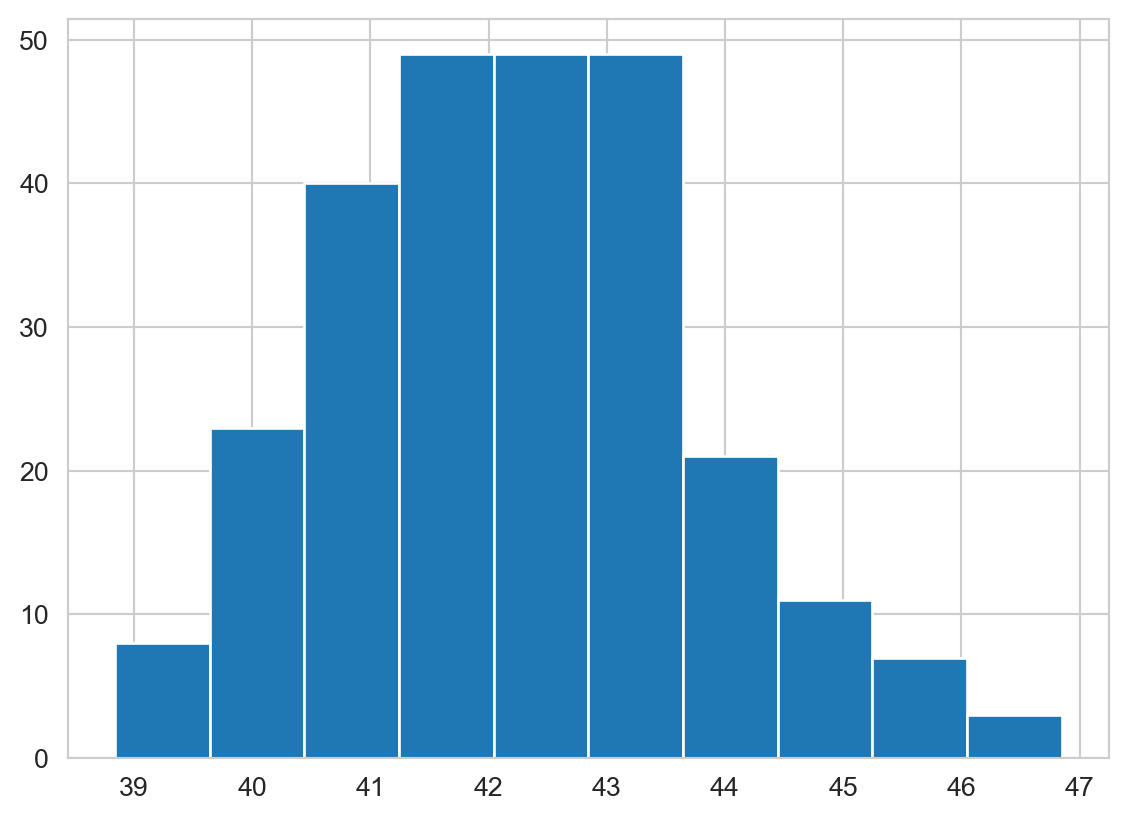

In [7]:
df['entrada_grasa_g_l'].hist()

Presentamos el boxplot al lado del histograma:

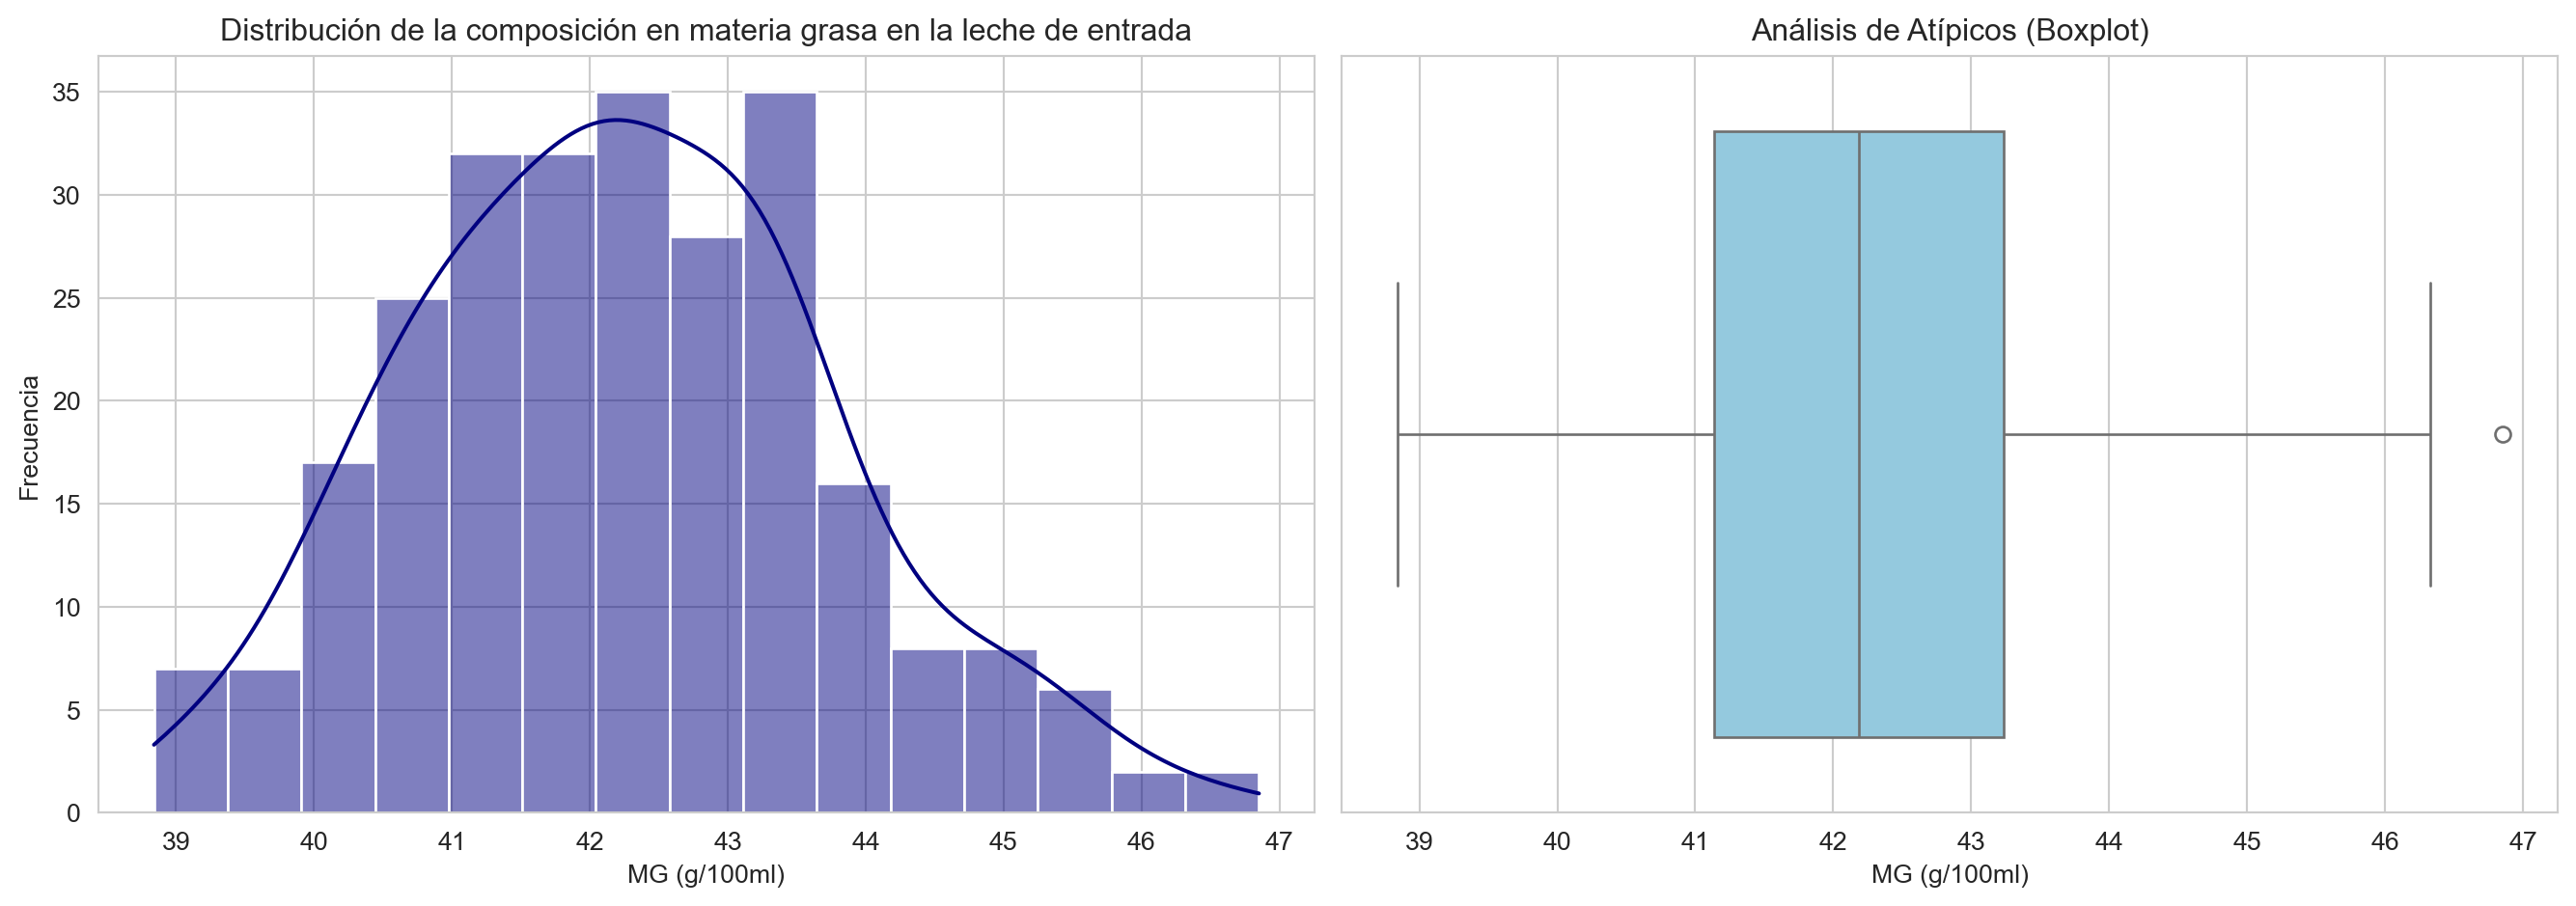

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la figura con 1 fila y 2 columnas
# figsize=(14, 5) da un buen ancho para que no se vean comprimidos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Gráfico de la izquierda: Histograma
sns.histplot(df['entrada_grasa_g_l'], kde=True, color='navy', bins=15, ax=ax1)
ax1.set_title('Distribución de la composición en materia grasa en la leche de entrada')
ax1.set_xlabel('MG (g/100ml)')
ax1.set_ylabel('Frecuencia')

# 3. Gráfico de la derecha: Boxplot
# Usamos orient='h' para que sea horizontal y sea fácil comparar con el histograma
sns.boxplot(x=df['entrada_grasa_g_l'], color='skyblue', ax=ax2)
ax2.set_title('Análisis de Atípicos (Boxplot)')
ax2.set_xlabel('MG (g/100ml)')

# 4. Ajustar el espacio entre los dos gráficos para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

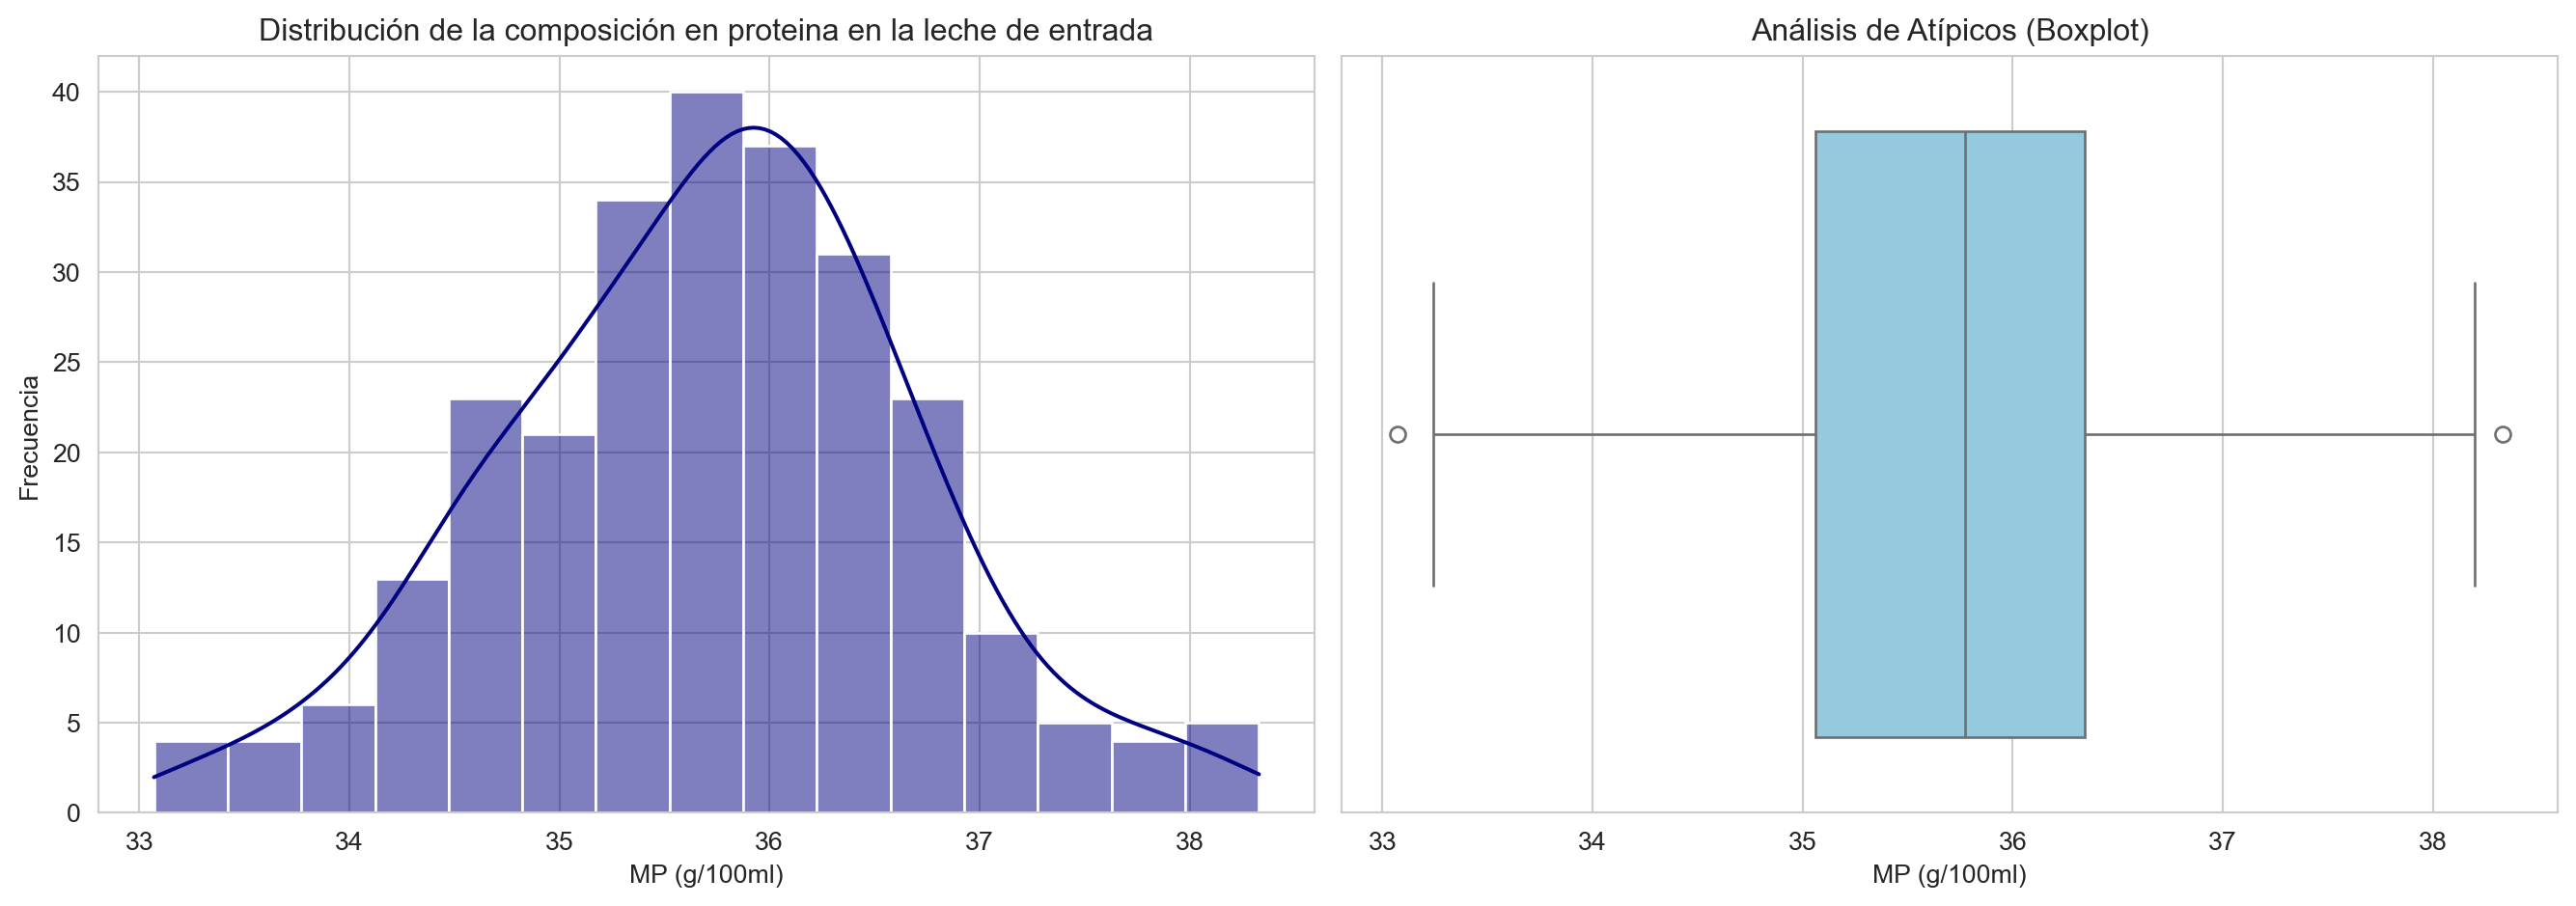

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la figura con 1 fila y 2 columnas
# figsize=(14, 5) da un buen ancho para que no se vean comprimidos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Gráfico de la izquierda: Histograma
sns.histplot(df['entrada_prot_g_l'], kde=True, color='navy', bins=15, ax=ax1)
ax1.set_title('Distribución de la composición en proteina en la leche de entrada')
ax1.set_xlabel('MP (g/100ml)')
ax1.set_ylabel('Frecuencia')

# 3. Gráfico de la derecha: Boxplot
# Usamos orient='h' para que sea horizontal y sea fácil comparar con el histograma
sns.boxplot(x=df['entrada_prot_g_l'], color='skyblue', ax=ax2)
ax2.set_title('Análisis de Atípicos (Boxplot)')
ax2.set_xlabel('MP (g/100ml)')

# 4. Ajustar el espacio entre los dos gráficos para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

En general, no parece que haya datos anómalos ni en la MG ni en la MP, salvo un outlier en ambos casos. Si fuese la misma muestra la que presenta esos resultados anómalos, podría tratarse de una muestra mal tomada, o bien de un valor excepcional. Para ver si se trata del mismo caso, representamos la MG y la MP con un diagrama de dispersión:

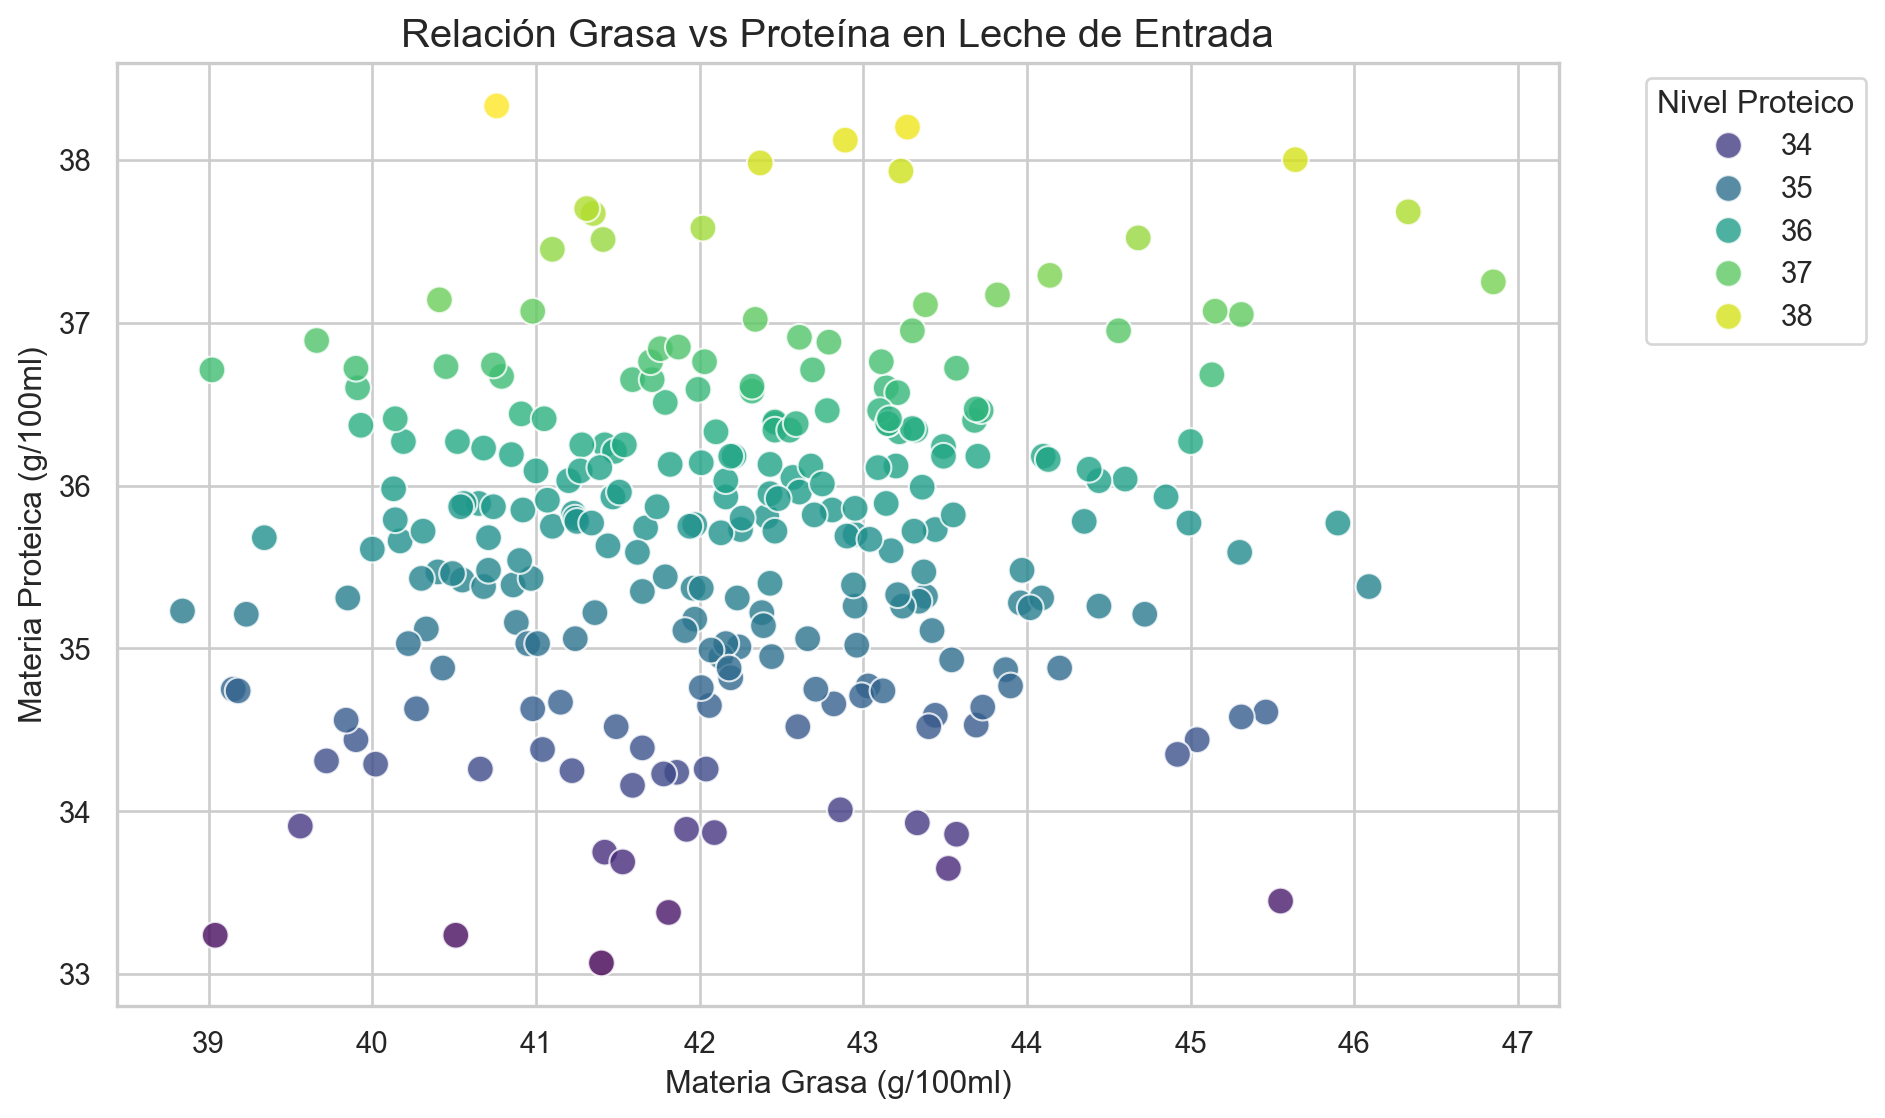

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo para que sea más profesional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Creamos el scatterplot
sns.scatterplot(
    data=df, 
    x='entrada_grasa_g_l', 
    y='entrada_prot_g_l', 
    hue='entrada_prot_g_l', # El color cambia según la proteína para dar más dimensión
    palette='viridis',     # Una paleta de colores elegante
    alpha=0.8, 
    edgecolor='w', 
    s=100                 # Tamaño de los puntos
)

# Añadimos títulos y etiquetas claras
plt.title('Relación Grasa vs Proteína en Leche de Entrada', fontsize=15)
plt.xlabel('Materia Grasa (g/100ml)')
plt.ylabel('Materia Proteica (g/100ml)')

# Mejoramos la leyenda y el layout
plt.legend(title='Nivel Proteico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

A la vista del gráfico, no parece que los outliers que detectamos en el boxplot se correspondan a l amisma muestra, no hay ningún punto que se destaque simultáneamente para ambos parámetros.

Veamos las entradas en el tiempo.

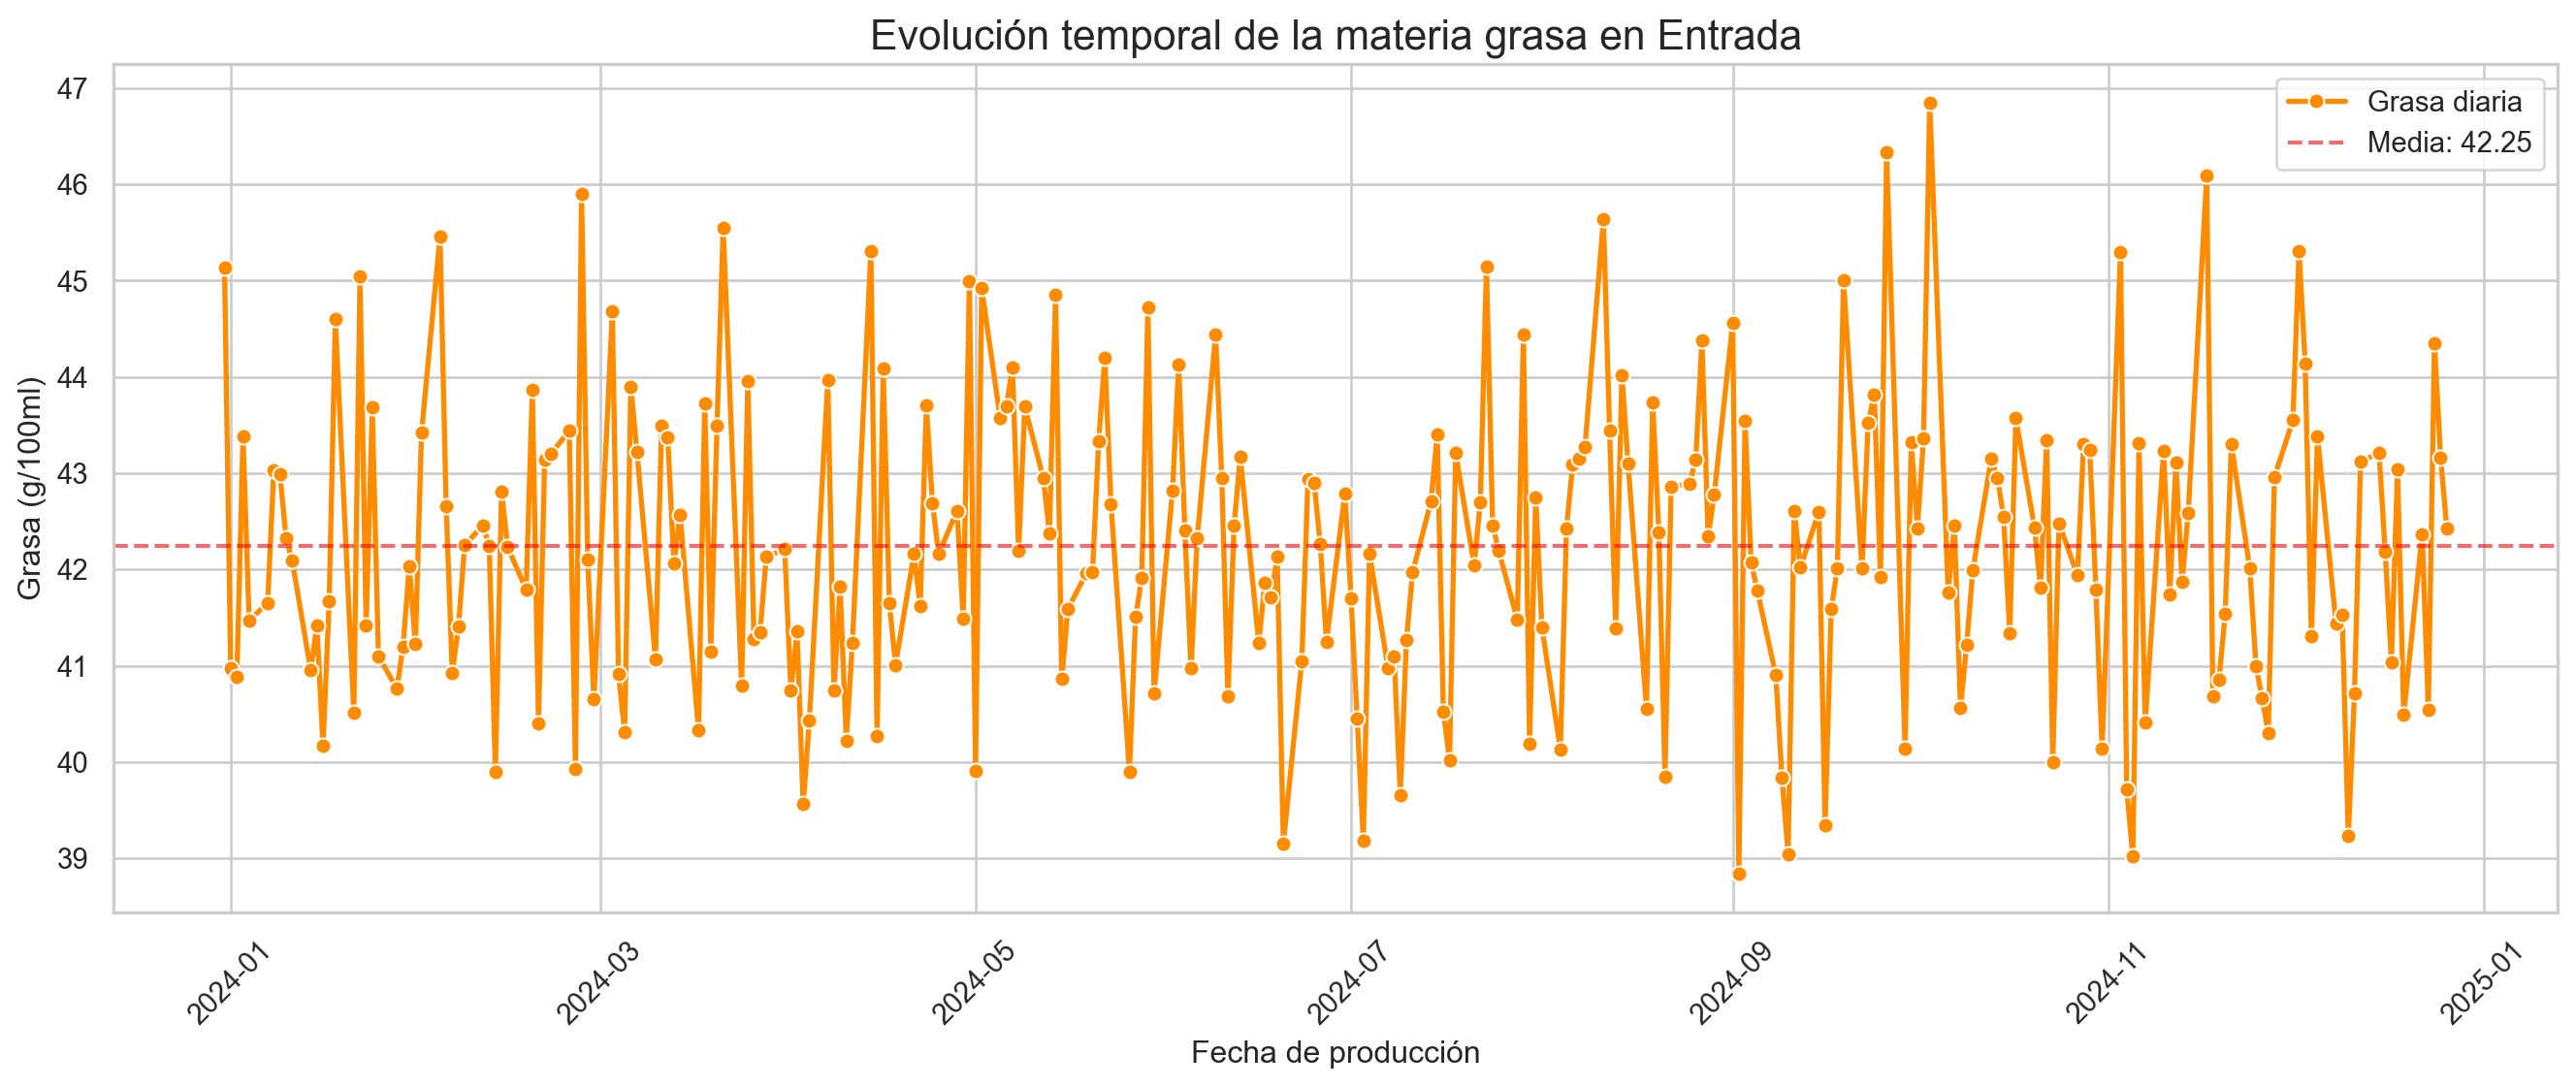

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el estilo y tamaño
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 2. Crear el gráfico de líneas
sns.lineplot(
    data=df, 
    x='fecha', 
    y='entrada_grasa_g_l', 
    marker='o',           # Añade puntos en cada medición
    color='darkorange',    # Color que resalte
    linewidth=2,
    label='Grasa diaria'
)

# 3. Añadir una línea de la media general (opcional, para referencia)
media_grasa = df['entrada_grasa_g_l'].mean()
plt.axhline(media_grasa, color='red', linestyle='--', alpha=0.6, label=f'Media: {media_grasa:.2f}')

# 4. Personalización de etiquetas y títulos
plt.title('Evolución temporal de la materia grasa en Entrada', fontsize=16)
plt.xlabel('Fecha de producción', fontsize=12)
plt.ylabel('Grasa (g/100ml)', fontsize=12)

# Rotar las fechas para que no se amontonen
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

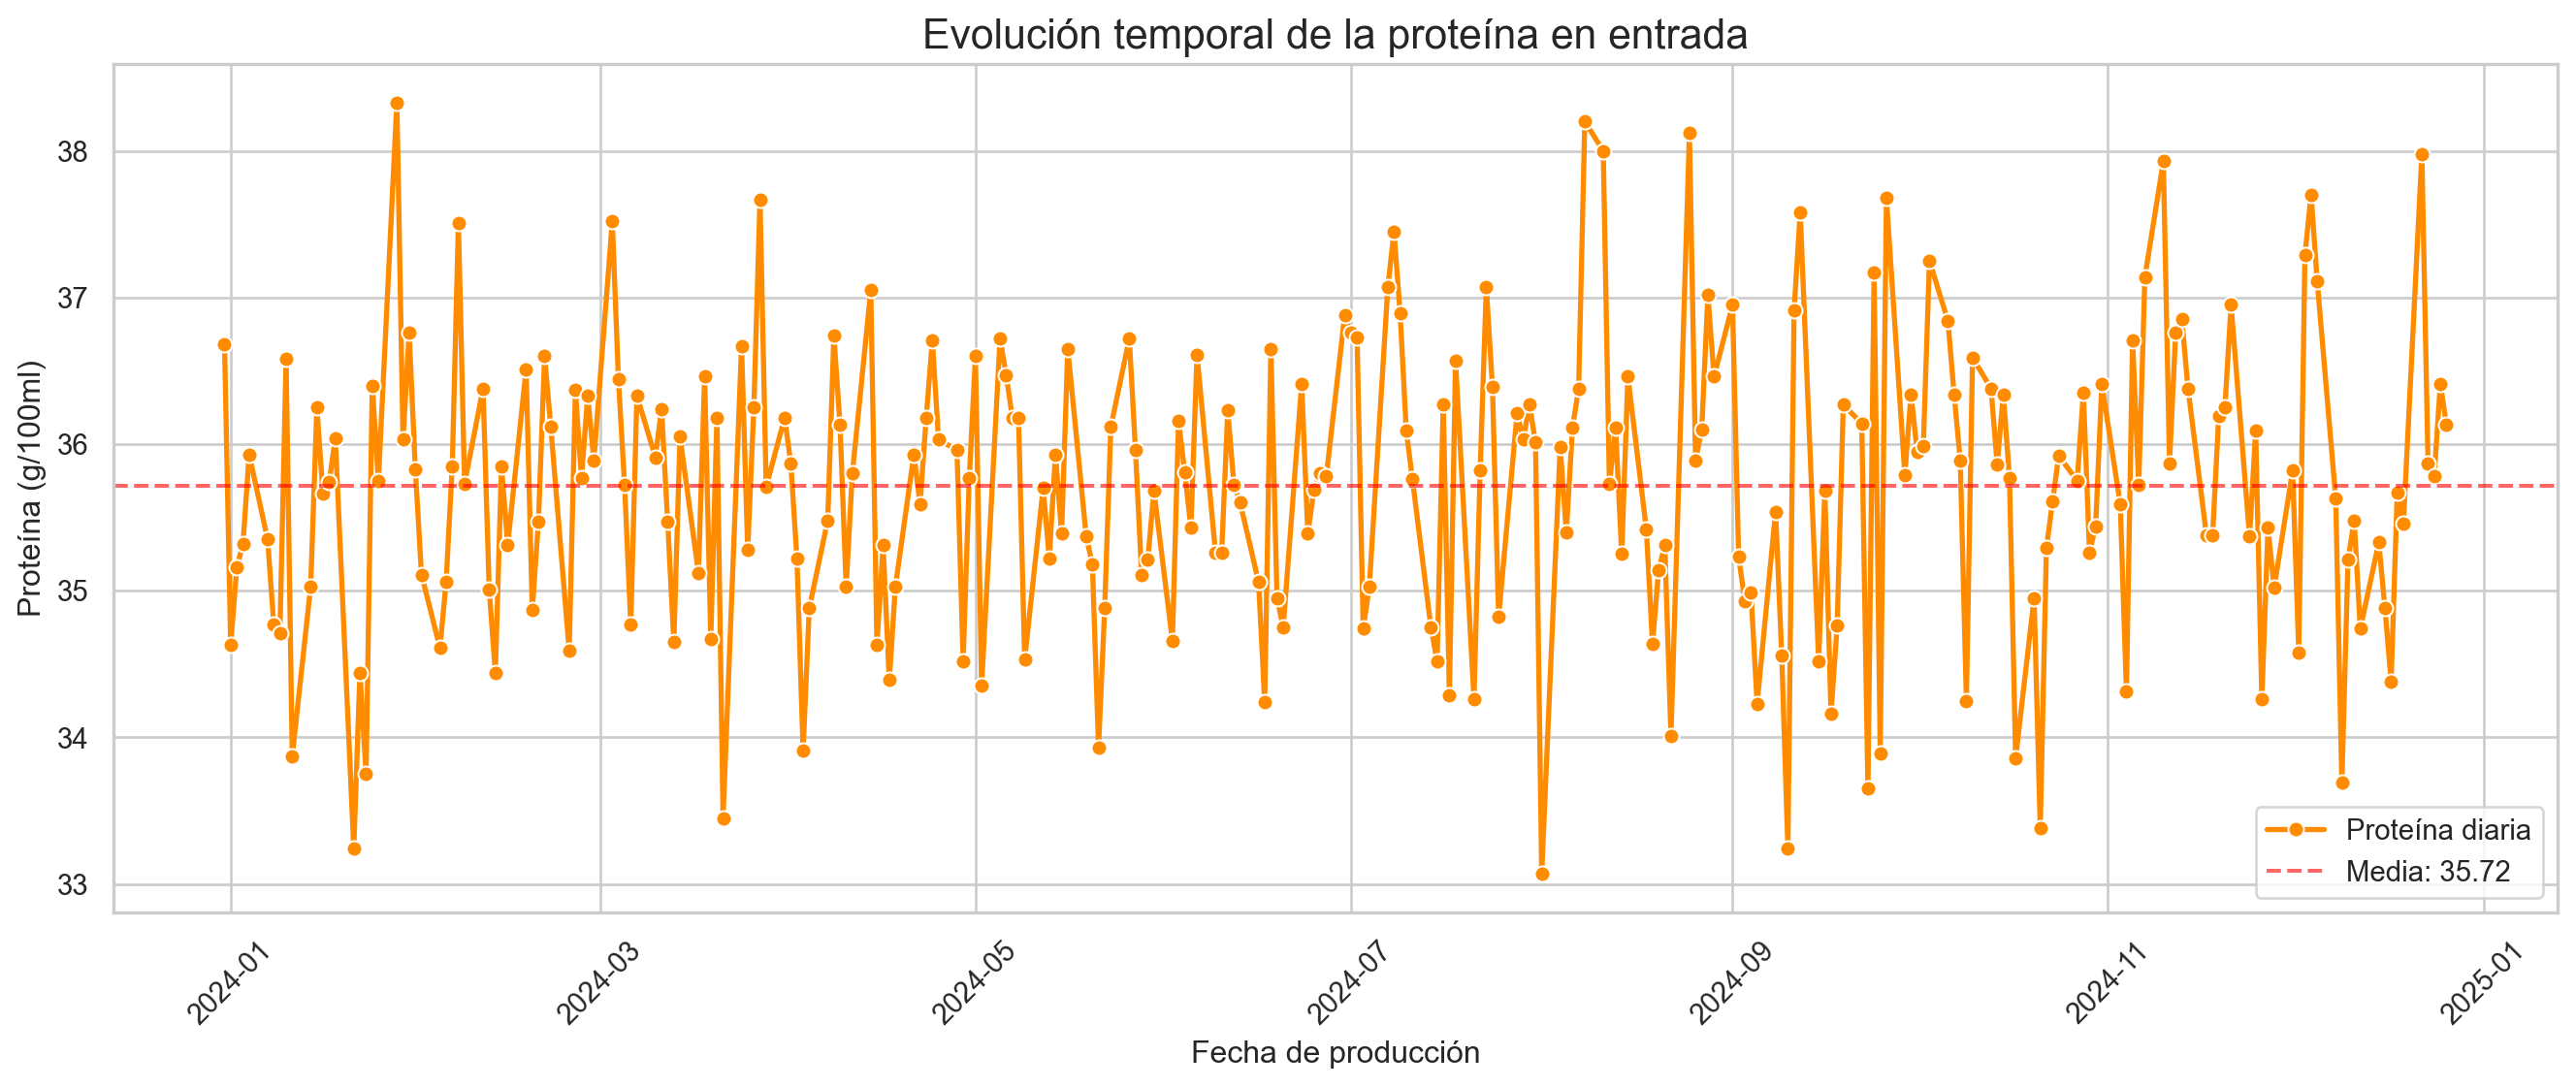

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el estilo y tamaño
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 2. Crear el gráfico de líneas
sns.lineplot(
    data=df, 
    x='fecha', 
    y='entrada_prot_g_l', 
    marker='o',           # Añade puntos en cada medición
    color='darkorange',    # Color que resalte
    linewidth=2,
    label='Proteína diaria'
)

# 3. Añadir una línea de la media general (opcional, para referencia)
media_grasa = df['entrada_prot_g_l'].mean()
plt.axhline(media_grasa, color='red', linestyle='--', alpha=0.6, label=f'Media: {media_grasa:.2f}')

# 4. Personalización de etiquetas y títulos
plt.title('Evolución temporal de la proteína en entrada', fontsize=16)
plt.xlabel('Fecha de producción', fontsize=12)
plt.ylabel('Proteína (g/100ml)', fontsize=12)

# Rotar las fechas para que no se amontonen
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

No parece que haya valores extremos anómalos, ni tendencias marcadas en ninguno de los dos parámetros analíticos de la leche, por lo que podemos hacer los cálculos agregados sin más consideraciones. Calculamos la composición de la leche usando los cálculos lineales:

In [13]:
leche_media_mg = df['entrada_grasa_g_l'].mean()
leche_mediana_mg = df['entrada_grasa_g_l'].median()

leche_media_mp = df['entrada_prot_g_l'].mean()
leche_mediana_mp = df['entrada_prot_g_l'].median()

print("Datos analíticos de la leche de entrada en g/L")
print(f"Media MG    : {leche_media_mg:.2f}")
print(f"Mediana MG  : {leche_mediana_mg:.2f}")
print(f"Media MP    : {leche_media_mp:.2f}")
print(f"Mediana MP  : {leche_mediana_mp:.2f}")

Datos analíticos de la leche de entrada en g/L
Media MG    : 42.25
Mediana MG  : 42.19
Media MP    : 35.72
Mediana MP  : 35.78


Hemos visto que la distribución de los datos es caso simétrica (semejante a una campana de Gauss). Por esta razón, la media y la mediana tienen valores casi idénticos.


### Analítica del queso

Completamos los datos analíticos del queso calculando los parámetros que nos faltan y que vamos a necesitar, así como algunos totales, antes de pasar a los cálculos agregados y gráficos.

In [14]:
### Cálculos de totales en queso 
df['queso_est_kg'] = df['queso_kg'] * df['queso_est_pct'] / 100
df['queso_mg_kg'] =  df['queso_kg'] * df['queso_mg_pct'] / 100
df['queso_esm_kg'] = df['queso_est_kg'] - df['queso_mg_kg']

# resto de cálculos analíticos del queso
df['queso_esm_pct'] = (df['queso_esm_kg'] / df['queso_kg'] * 100)
df['queso_hqd_pct'] = (100 - df['queso_est_pct'])/(100 - df['queso_mg_pct']) * 100
df['queso_ges_pct'] = df['queso_mg_pct'] / df['queso_est_pct'] * 100

Empezamos la exploración de los datos:

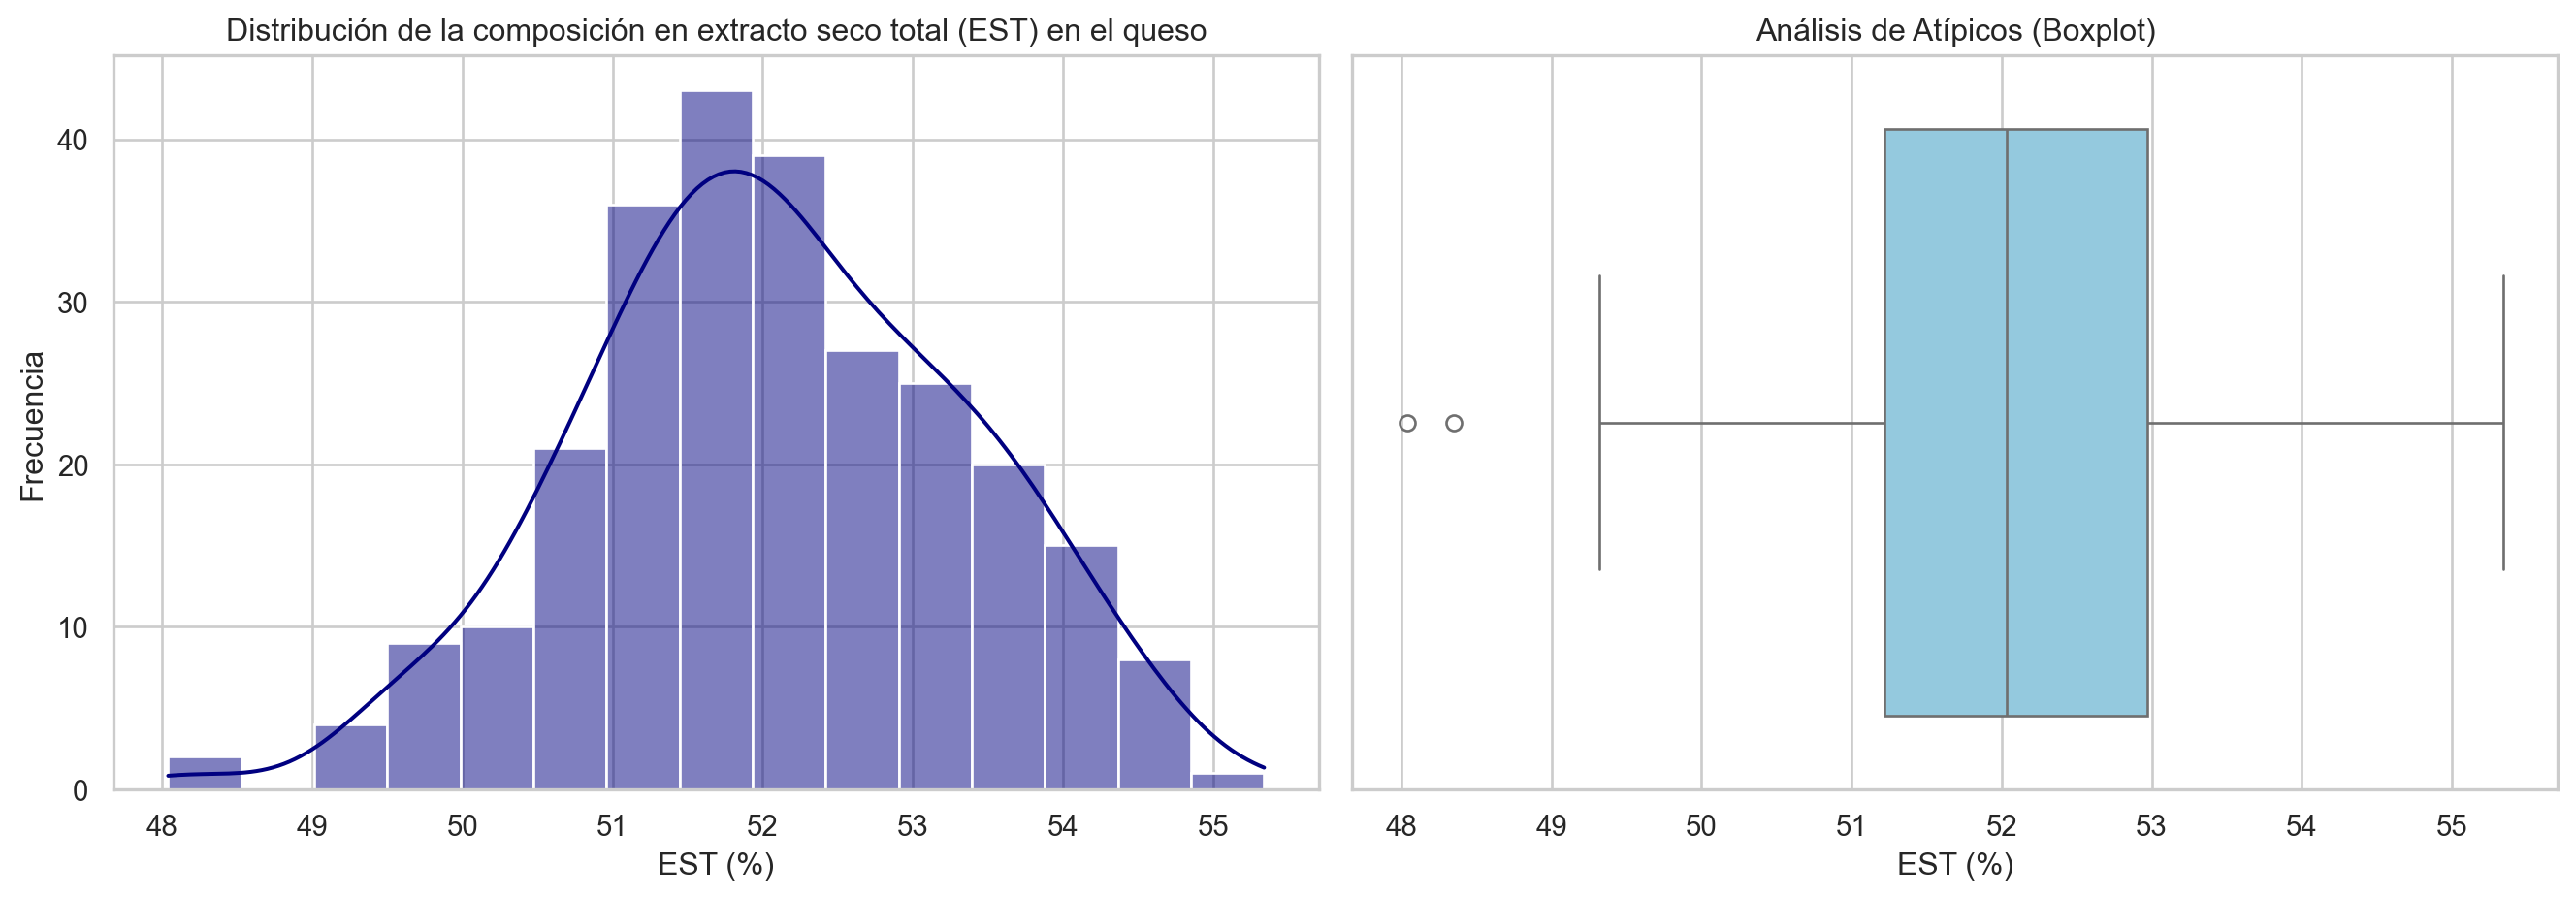

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la figura con 1 fila y 2 columnas
# figsize=(14, 5) da un buen ancho para que no se vean comprimidos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Gráfico de la izquierda: Histograma
sns.histplot(df['queso_est_pct'], kde=True, color='navy', bins=15, ax=ax1)
ax1.set_title('Distribución de la composición en extracto seco total (EST) en el queso')
ax1.set_xlabel('EST (%)')
ax1.set_ylabel('Frecuencia')

# 3. Gráfico de la derecha: Boxplot
# Usamos orient='h' para que sea horizontal y sea fácil comparar con el histograma
sns.boxplot(x=df['queso_est_pct'], color='skyblue', ax=ax2)
ax2.set_title('Análisis de Atípicos (Boxplot)')
ax2.set_xlabel('EST (%)')

# 4. Ajustar el espacio entre los dos gráficos para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

Aparecen dos valores extremos en la parte baja de la distribución, en torno a 48. Veamos la MG.

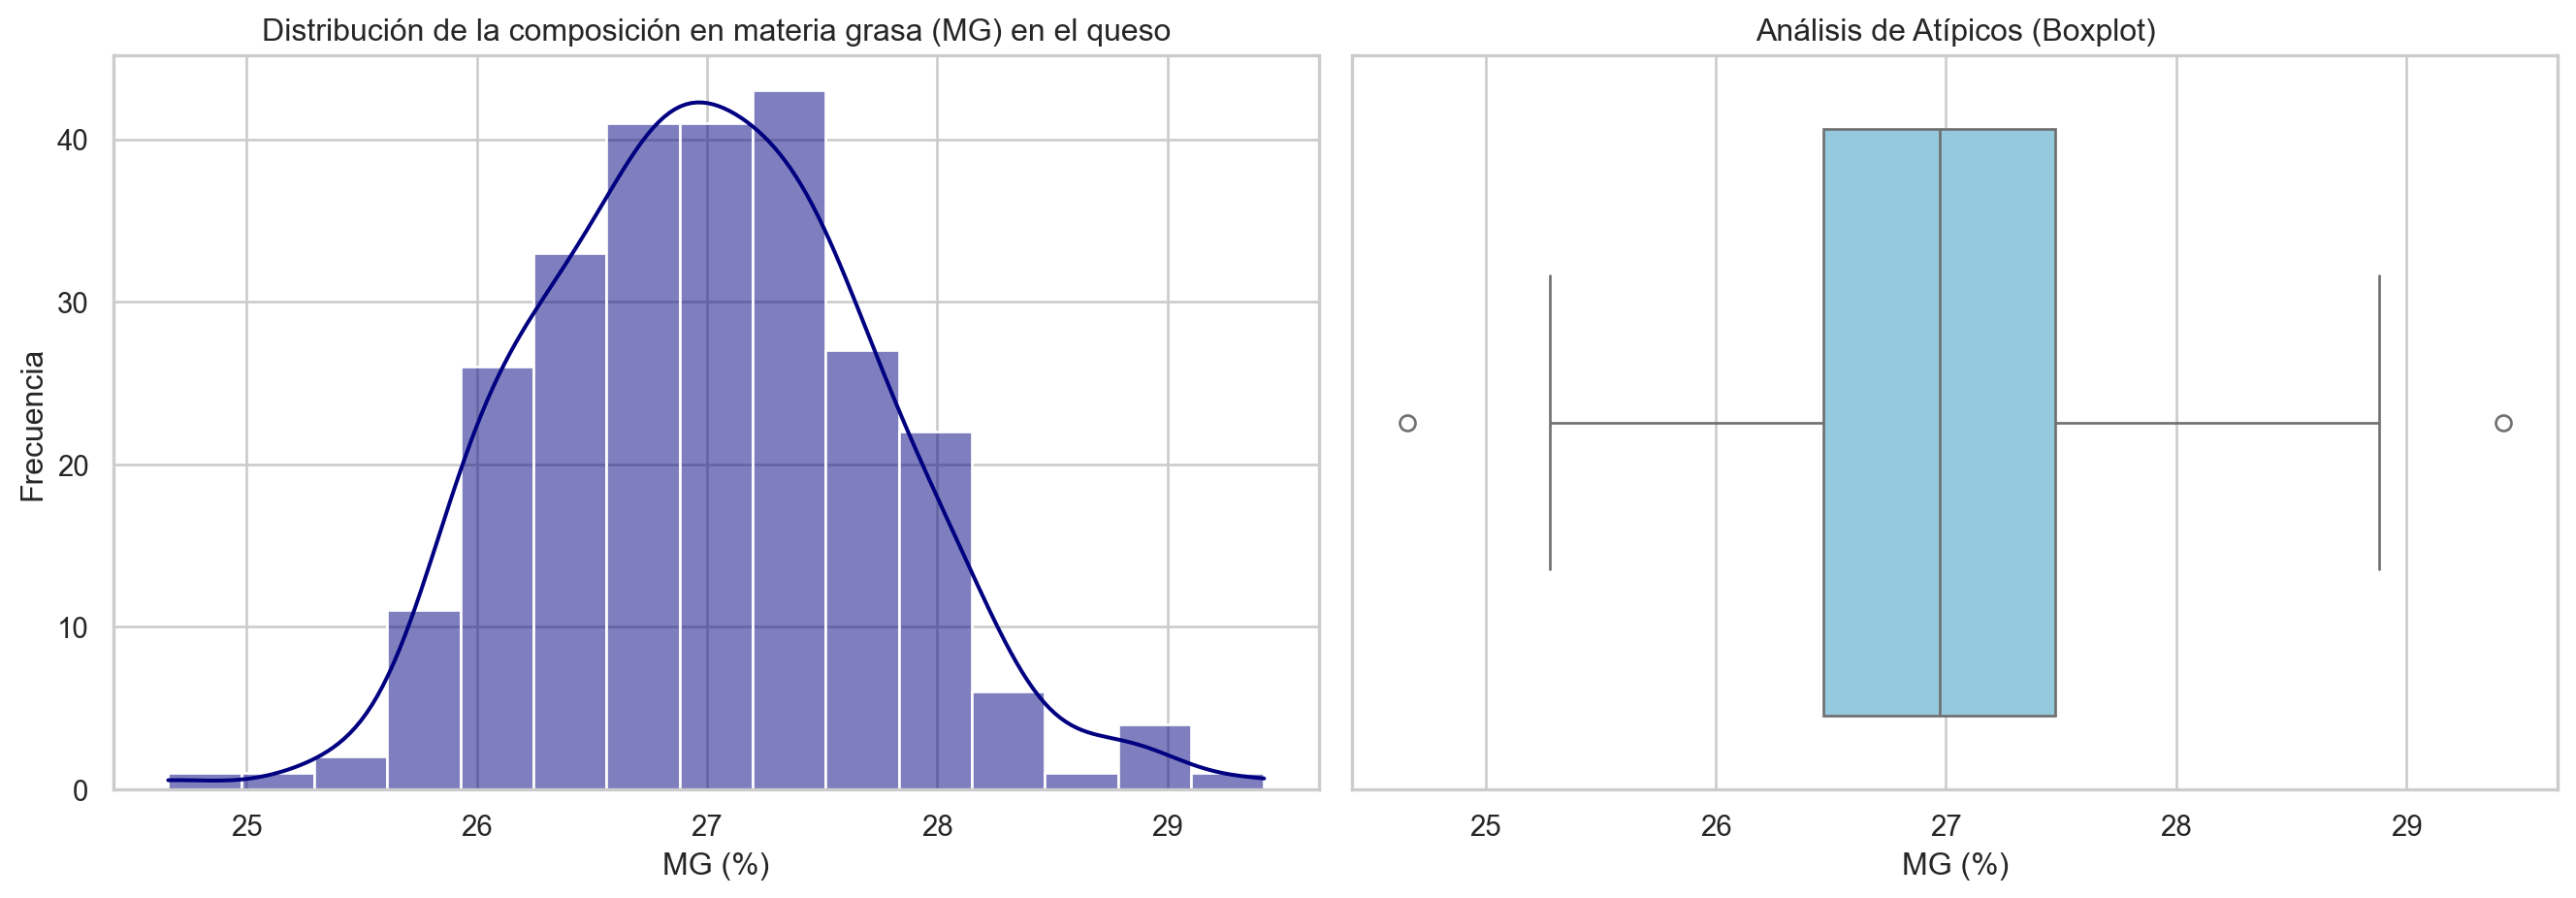

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la figura con 1 fila y 2 columnas
# figsize=(14, 5) da un buen ancho para que no se vean comprimidos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Gráfico de la izquierda: Histograma
sns.histplot(df['queso_mg_pct'], kde=True, color='navy', bins=15, ax=ax1)
ax1.set_title('Distribución de la composición en materia grasa (MG) en el queso')
ax1.set_xlabel('MG (%)')
ax1.set_ylabel('Frecuencia')

# 3. Gráfico de la derecha: Boxplot
# Usamos orient='h' para que sea horizontal y sea fácil comparar con el histograma
sns.boxplot(x=df['queso_mg_pct'], color='skyblue', ax=ax2)
ax2.set_title('Análisis de Atípicos (Boxplot)')
ax2.set_xlabel('MG (%)')

# 4. Ajustar el espacio entre los dos gráficos para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

Veamos la distribución conjunta.

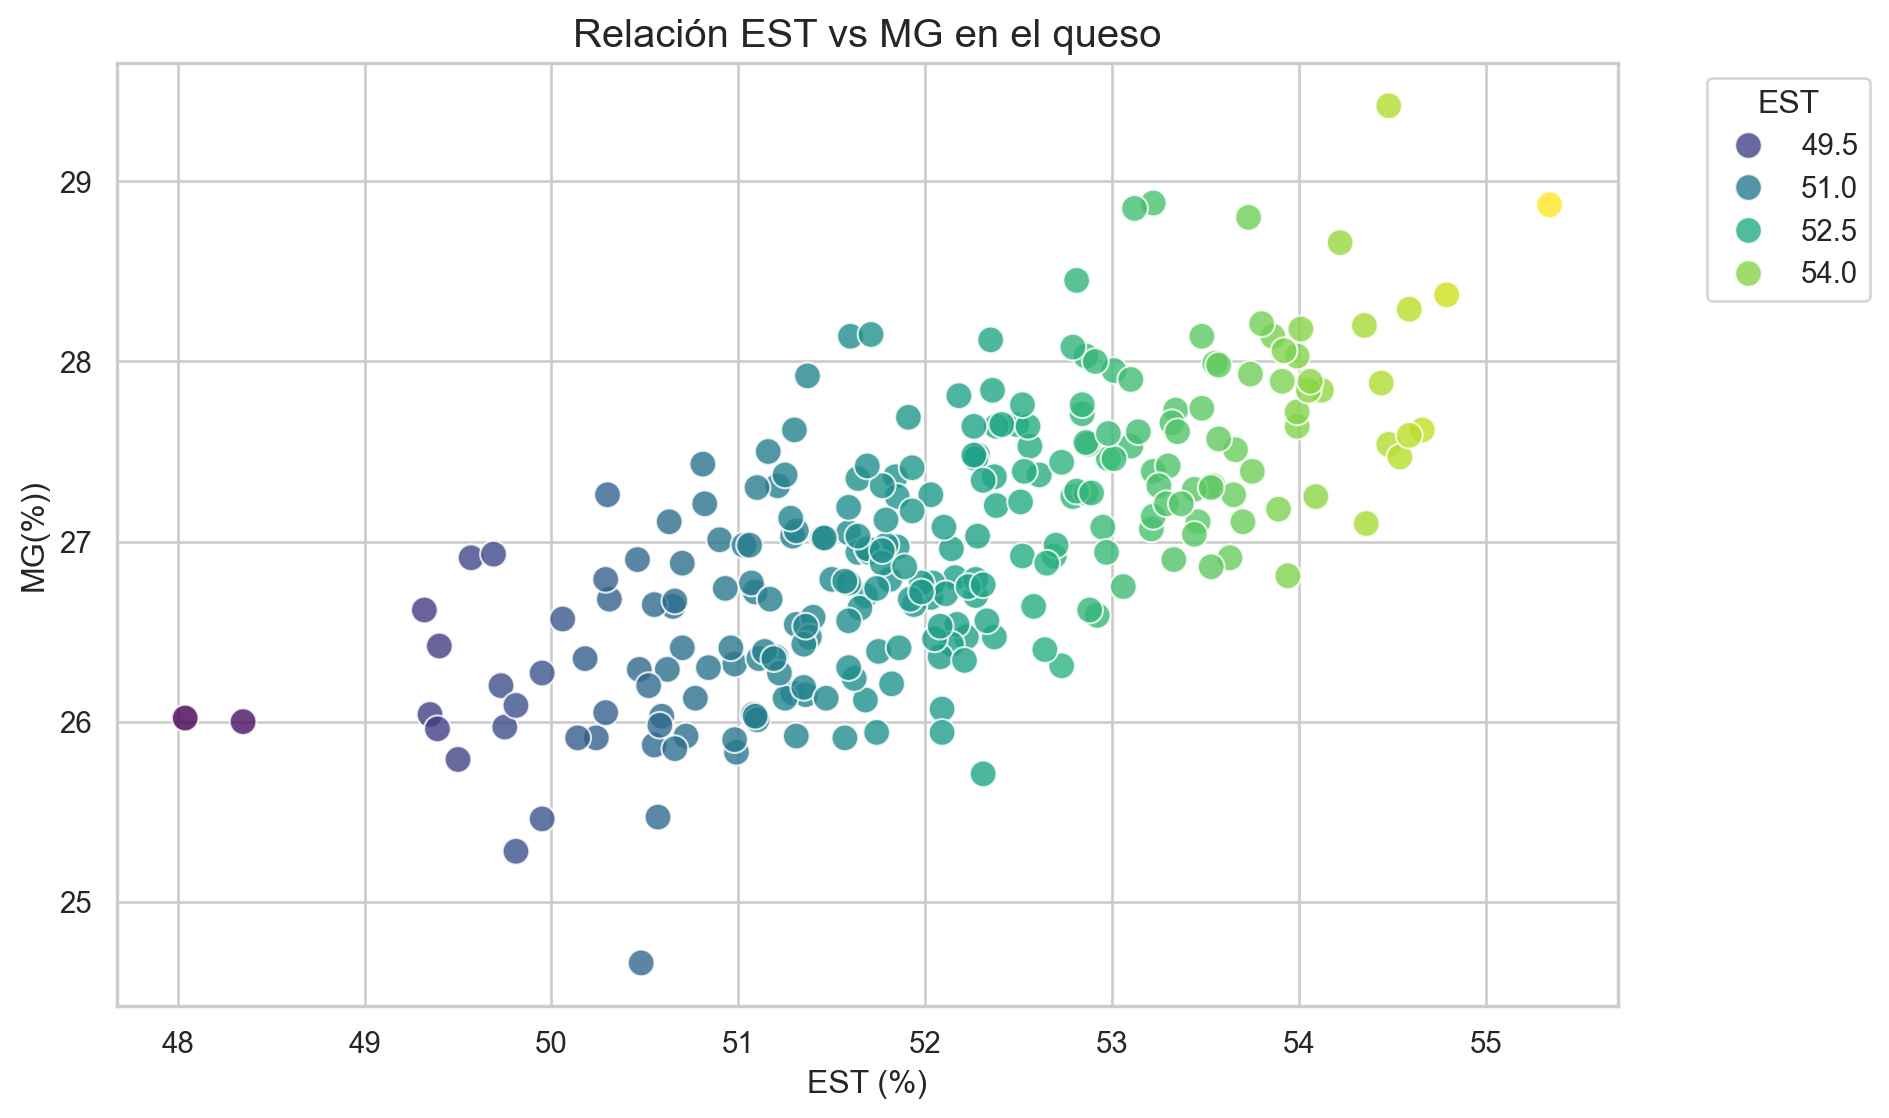

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo para que sea más profesional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Creamos el scatterplot
sns.scatterplot(
    data=df, 
    x='queso_est_pct', 
    y='queso_mg_pct', 
    hue='queso_est_pct', # El color cambia según la proteína para dar más dimensión
    palette='viridis',     # Una paleta de colores elegante
    alpha=0.8, 
    edgecolor='w', 
    s=100                 # Tamaño de los puntos
)

# Añadimos títulos y etiquetas claras
plt.title('Relación EST vs MG en el queso', fontsize=15)
plt.xlabel('EST (%)')
plt.ylabel('MG(%))')

# Mejoramos la leyenda y el layout
plt.legend(title='EST', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

En el gráfico se aprecia la correlación entre el EST y la MG, que es lógica, ya que en general un aumento del EST implica también un aumento de la MG si la grasa del extracto seco se mantiene más o menos constante.

Identificamos bien los dos valores anómalos de EST, pero no parece que se correspondan con valores anómalos de MG. También hay un valor muy bajo de MG que no aprece corresponderse con valores anormales de MG.

Veamos la evolución en el tiempo de estos parámetros.

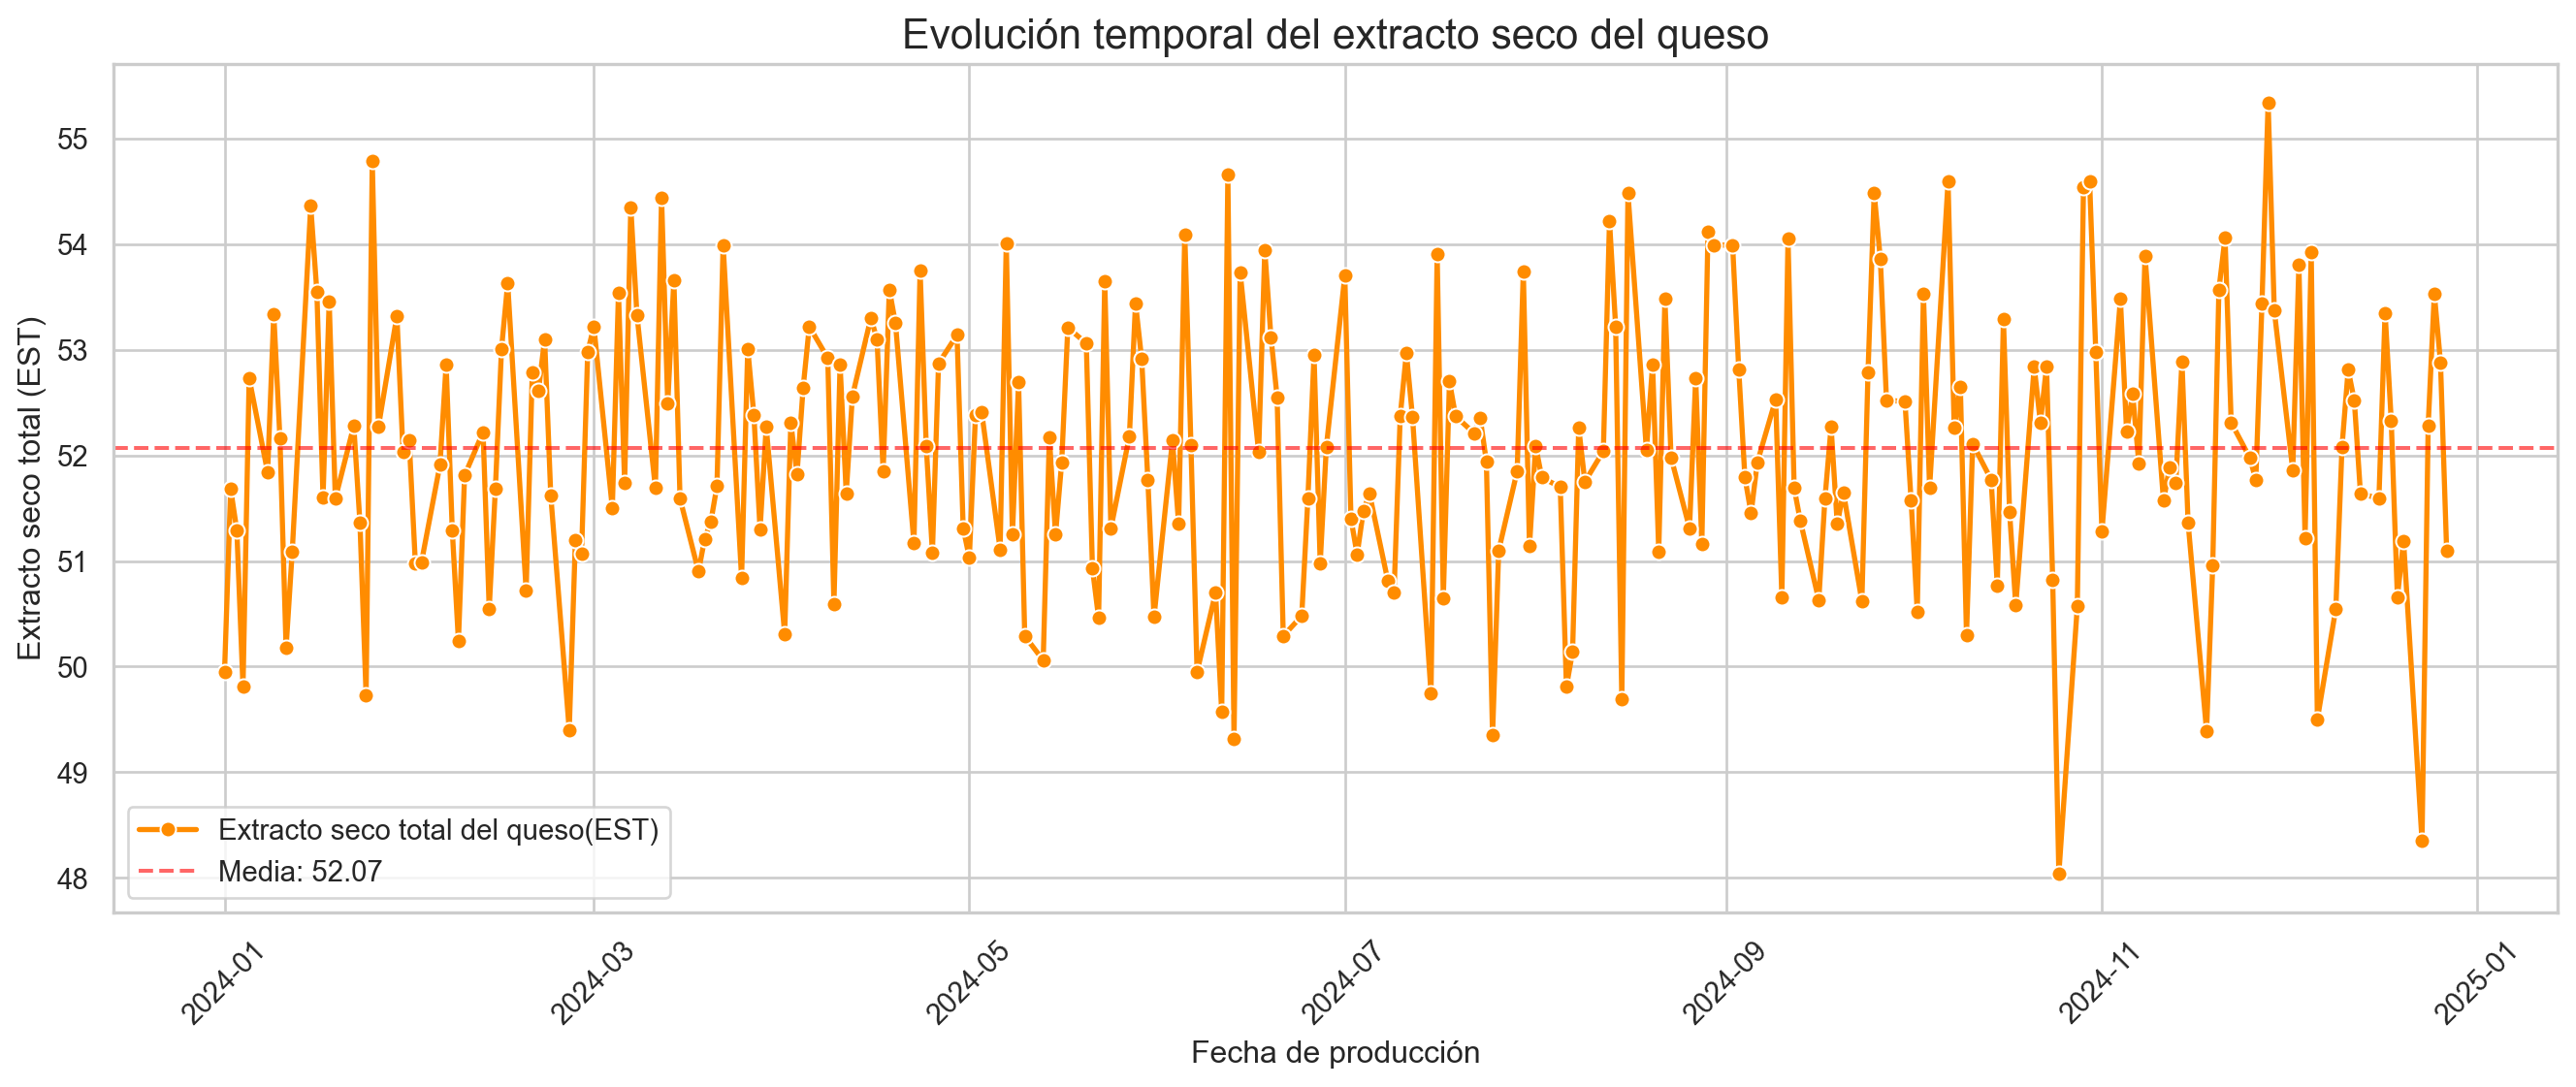

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el estilo y tamaño
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 2. Crear el gráfico de líneas
sns.lineplot(
    data=df, 
    x='fecha', 
    y='queso_est_pct', 
    marker='o',           # Añade puntos en cada medición
    color='darkorange',    # Color que resalte
    linewidth=2,
    label='Extracto seco total del queso(EST)'
)

# 3. Añadir una línea de la media general (opcional, para referencia)
media_grasa = df['queso_est_pct'].mean()
plt.axhline(media_grasa, color='red', linestyle='--', alpha=0.6, label=f'Media: {media_grasa:.2f}')

# 4. Personalización de etiquetas y títulos
plt.title('Evolución temporal del extracto seco del queso', fontsize=16)
plt.xlabel('Fecha de producción', fontsize=12)
plt.ylabel('Extracto seco total (EST)', fontsize=12)

# Rotar las fechas para que no se amontonen
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

Una vez explorados los datos, y sin anomalías reseñables, obtenemos los estadísticos agregados del conjunto de la fabricación.

In [19]:
# Calcular media y mediana lineales
media_est = df['queso_est_pct'].mean()
mediana_est = df['queso_est_pct'].median()

media_mg = df['queso_mg_pct'].mean()
mediana_mg = df['queso_mg_pct'].median()

media_hqd = df['queso_hqd_pct'].mean()
mediana_hqd = df['queso_hqd_pct'].median()

media_ges = df['queso_ges_pct'].mean()
mediana_ges = df['queso_ges_pct'].median()

print("Media EST: ", media_est)
print("Mediana EST: ",mediana_est)
print("Media MG: ",media_mg)
print("Mediana MG: ",mediana_mg)
print("Media HQD: ",media_hqd)
print("Mediana HQD: ",mediana_hqd)
print("Media GES: ",media_ges)
print("Mediana GES: ",mediana_ges)

Media EST:  52.06742307692308
Mediana EST:  52.035
Media MG:  26.99780769230769
Mediana MG:  26.975
Media HQD:  65.65351725379274
Mediana HQD:  65.69245975624996
Media GES:  51.859490974611866
Mediana GES:  51.81211251206409


Si quisiéramos ser más precisos en el cálculo, en vez de la media de los valores analíticos, deberíamos calcular la media ponderada de nuestras entradas, calculando el total de EST del queso que hemos fabricado, y dividiendo esta cantidad entre el total de kilos obtenidos.  A continuación, calculamos las cantidades ponderadas y formateamos la salida con dos decimales (utilizamos una opcion para alinear los datos impresos en el punto decimal):

In [20]:
num_fabricaciones = df.dropna(subset=["queso_kg", "queso_est_pct"]).shape[0]

queso_total_kg = df["queso_kg"].sum()

queso_total_EST_kg = (df["queso_kg"]*df["queso_est_pct"]/100).sum()
queso_media_pond_EST = queso_total_EST_kg/queso_total_kg * 100

queso_total_MG_kg = (df["queso_kg"]*df["queso_mg_pct"]/100).sum()
queso_media_pond_MG = queso_total_MG_kg/queso_total_kg * 100

queso_total_ESM_kg = queso_total_EST_kg - queso_total_MG_kg
queso_media_pond_ESM = queso_total_ESM_kg/queso_total_kg * 100

# Definimos un ancho para la columna de valores, para alinear los valores a la derecha
ancho = 12

print("ANALÍTICAS DEL QUESO FABRICADO")
print("-" * 45) # Una línea separadora ayuda a la lectura
print(f"Se han realizado {num_fabricaciones} fabricaciones de queso")
print(f"Total kg de queso  : {queso_total_kg:>{ancho}.2f}")
print(f"Total kg de EST    : {queso_total_EST_kg:>{ancho}.2f}")
print(f"Media ponderada EST: {queso_media_pond_EST:>{ancho}.2f}%")
print(f"Total kg de MG     : {queso_total_MG_kg:>{ancho}.2f}")
print(f"Media ponderada MG : {queso_media_pond_MG:>{ancho}.2f}%")
print(f"Total kg de ESM    : {queso_total_ESM_kg:>{ancho}.2f}")
print(f"Media ponderada ESM: {queso_media_pond_ESM:>{ancho}.2f}%")


ANALÍTICAS DEL QUESO FABRICADO
---------------------------------------------
Se han realizado 260 fabricaciones de queso
Total kg de queso  :    163794.66
Total kg de EST    :     85248.43
Media ponderada EST:        52.05%
Total kg de MG     :     44205.77
Media ponderada MG :        26.99%
Total kg de ESM    :     41042.66
Media ponderada ESM:        25.06%


## Cálculo de los coeficientes de recuperación

Siguiendo el método de cálculo del capitulo anterior, ahora necesitamos conocer cuál es la tasa o ratio de conversión en ESM de queso de la MP de la leche en cubas. Para ello calculamos los **coeficientes de recuperación de MG y de MP**, y los **consumos de materia**.

In [21]:
### Coeficientes de recuperación (expresado en porcentaje)
df['coef_recup_mg']  = df['queso_mg_kg']/df['cuba_mg_kg'] * 100
df['coef_recup_mp']  = df['queso_esm_kg']/df['cuba_mp_kg'] * 100 

### Consumos de materia por kilo de queso (g / kg)
df['consumo_mg_kg']  = df['cuba_mg_kg']/df['queso_kg'] * 1000
df['consumo_mp_kg']  = df['cuba_mp_kg']/df['queso_kg'] * 1000 

# para evitar desbordamiento de la linea, 
# podemos dividir el texto a imprimir en varias lineas
print(
    f"Coef. de recuperación de MG "
    f"(MG queso/MG leche en cuba): "
    f"{df['coef_recup_mg'].mean():.2f}%"
)

print(
    f"Coef. de recuperación de MP "
    f"(ESM queso/MP leche en cuba): "
    f"{df['coef_recup_mp'].mean():.2f}%"
)

print(f"Consumo de MG por kg de queso: {df['consumo_mg_kg'].mean():.2f} g")
print(f"Consumo de MP por kg de queso: {df['consumo_mp_kg'].mean():.2f} g")

Coef. de recuperación de MG (MG queso/MG leche en cuba): 83.85%
Coef. de recuperación de MP (ESM queso/MP leche en cuba): 92.04%
Consumo de MG por kg de queso: 322.64 g
Consumo de MP por kg de queso: 272.80 g


## Otros cálculos teóricos del estándar técnico, para cada fabricación.

Finalmente, podemos hacer el cálculo del litraje unitario teórico, según el estándar técnico:

In [22]:
# Litrajes unitarios: 
# (g ESM en queso por kilo de queso) / (g MP leche en cuba por litro de leche) 
df['litraje_unitario'] = (
    (df['queso_esm_kg'] / df['queso_kg']) * 100 / 
    ((df['cuba_fab_prot_g_l'] / 1000) * df['coef_recup_mp'])
)

Ya tenemos todos nuestros cálculos línea a línea en el dataframe, que podemos inspeccionar de nuevo:

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 2023-12-31 to 2024-12-28
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha                364 non-null    datetime64[ns]
 1   entrada_kg           260 non-null    float64       
 2   entrada_litros       260 non-null    float64       
 3   entrada_grasa_g_l    260 non-null    float64       
 4   entrada_prot_g_l     260 non-null    float64       
 5   cuba_fab_litros      260 non-null    float64       
 6   cuba_fab_grasa_g_l   260 non-null    float64       
 7   cuba_fab_prot_g_l    260 non-null    float64       
 8   stock_cierre_litros  260 non-null    float64       
 9   queso_kg             260 non-null    float64       
 10  queso_est_pct        260 non-null    float64       
 11  queso_mg_pct         260 non-null    float64       
 12  cuba_mg_kg           260 non-null    float64       
 13  cuba_mp_kg      

In [24]:
df.head()

,fecha,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,cuba_fab_litros,cuba_fab_grasa_g_l,cuba_fab_prot_g_l,stock_cierre_litros,queso_kg,...,queso_mg_kg,queso_esm_kg,queso_esm_pct,queso_hqd_pct,queso_ges_pct,coef_recup_mg,coef_recup_mp,consumo_mg_kg,consumo_mp_kg,litraje_unitario
fecha_index,,,,,,,,,,,,,,,,,,,,,
2023-12-31,2023-12-31,4895.0,4752.0,45.13,36.68,NaN,NaN,NaN,4752.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01,2024-01-01,5516.0,5355.0,40.98,34.63,5025.0,41.07,33.95,5107.0,637.56,...,162.322776,156.138444,24.49,67.145157,50.970971,78.653616,91.523791,323.697770,267.580698,7.881611
2024-01-02,2024-01-02,4938.0,4794.0,40.88,35.16,5029.0,39.99,33.61,4901.0,630.34,...,164.644808,161.114904,25.56,65.403357,50.541796,81.868154,95.320337,319.049576,268.148444,7.978234
2024-01-03,2024-01-03,5704.0,5538.0,43.38,35.32,5032.0,40.55,33.85,5439.0,628.81,...,164.496696,158.019953,25.13,65.966956,51.004094,80.616825,92.771082,324.498020,270.881824,8.002417
2024-01-04,2024-01-04,5170.0,5019.0,41.47,35.93,5035.0,39.90,33.78,5458.0,656.69,...,166.011232,161.086057,24.53,67.170771,50.752861,82.635204,94.710653,305.922886,258.999376,7.667240


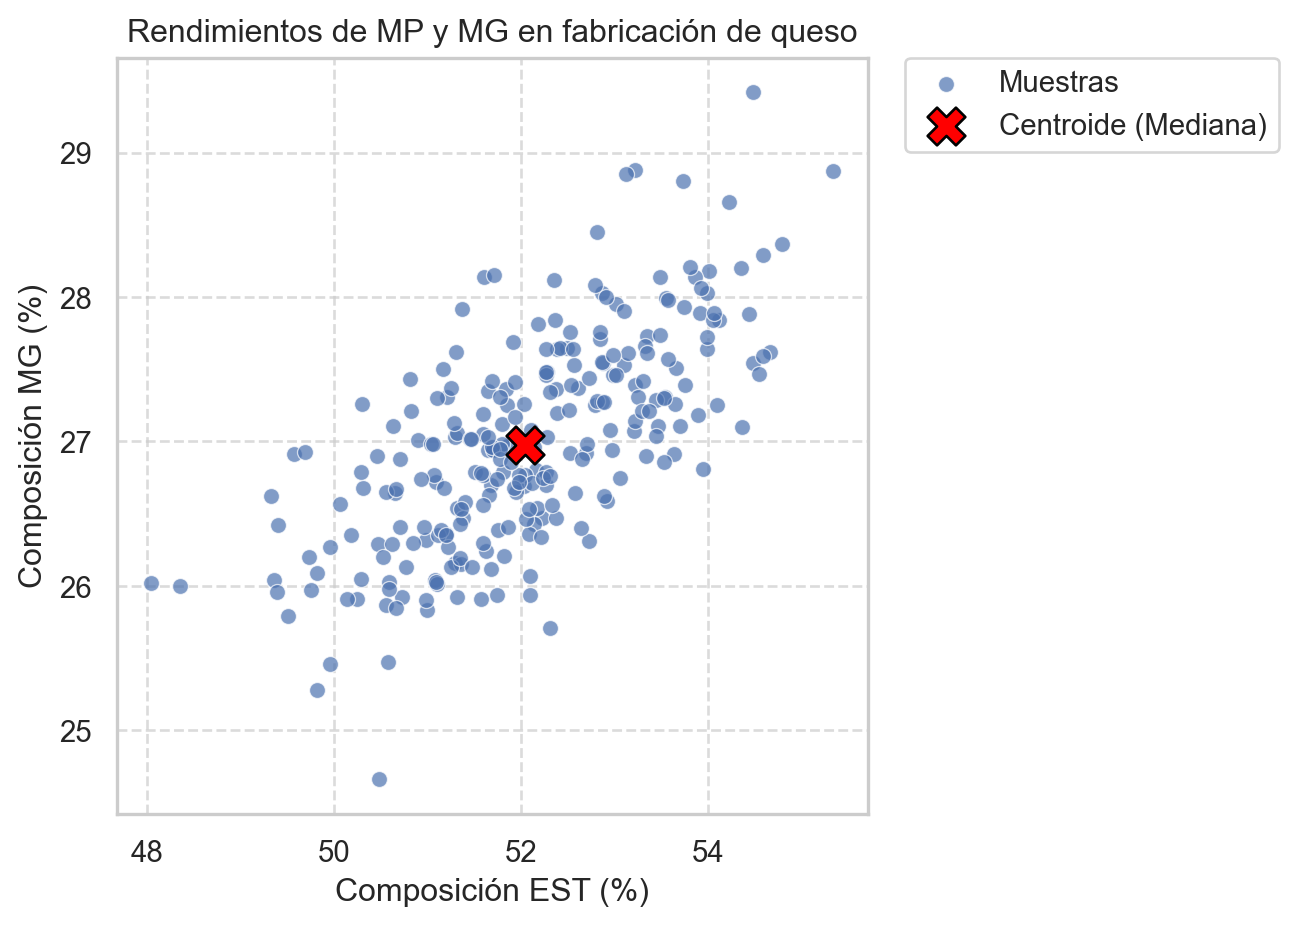

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración del scatterplot principal
sns.scatterplot(data=df, 
                x='queso_est_pct', 
                y='queso_mg_pct', 
                alpha=0.7,
                label='Muestras')

# 2. Calcular las medianas (Centroide)
# Usamos median() directamente sobre las columnas
mediana_est = df['queso_est_pct'].median()
mediana_mg = df['queso_mg_pct'].median()

# 3. Dibujar el centroide
# Pasamos los valores directamente como x e y
plt.scatter(
        mediana_est,
        mediana_mg,
        color='red',      # Un color que resalte
        marker='X',
        s=200,            # Un poco más grande para que se vea bien
        edgecolor='black',
        label='Centroide (Mediana)',
        zorder=5          # Asegura que el punto quede encima de los demás
    )

# 4. Estética del gráfico
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Composición EST (%)')
plt.ylabel('Composición MG (%)')

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Para que no se corte la leyenda al guardar/mostrar
plt.show()